# 🚛 Fleet Performance & Predictive Maintenance Analysis

## 1. Business Problem

Fleet breakdowns lead to operational disruptions, increased maintenance costs, and reduced service reliability.

### Objective:
To predict vehicle breakdown risk using operational and maintenance data, enabling proactive maintenance planning and improved fleet performance.

## 2. Data Generation (Synthetic Dataset)

A synthetic dataset was created to simulate real-world fleet operations while ensuring data privacy and compliance.

The dataset captures key aspects of fleet performance, including:

- Vehicle utilization and routing
- Delivery performance metrics
- Maintenance history
- Operational workload indicators

This approach allows for realistic analysis of breakdown risk without relying on sensitive or proprietary operational data.

In [47]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

The synthetic dataset was generated using controlled parameters to reflect real operational variability in logistics environments.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import print_model_results

from datetime import datetime, timedelta

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

In [49]:
# ==============================
# 🚛 Fleet Data Generation (Synthetic Dataset)
# ==============================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Ensure reproducibility
np.random.seed(42)

# ------------------------------
# Parameters
# ------------------------------
num_records = 2000
num_vehicles = 50
num_drivers = 80

# ------------------------------
# Generate Identifiers
# ------------------------------
vehicle_ids = [f"V{str(i).zfill(3)}" for i in np.random.randint(1, num_vehicles + 1, num_records)]
driver_ids = [f"D{str(i).zfill(3)}" for i in np.random.randint(1, num_drivers + 1, num_records)]

# ------------------------------
# Generate Dates
# ------------------------------
start_date = datetime(2025, 1, 1)
dates = [start_date + timedelta(days=int(x)) for x in np.random.randint(0, 90, num_records)]

# ------------------------------
# Route Types
# ------------------------------
route_types = np.random.choice(
    ['Urban', 'Suburban', 'Rural'],
    num_records,
    p=[0.5, 0.3, 0.2]
)

# ------------------------------
# Operational Metrics
# ------------------------------
total_stops = np.random.randint(80, 180, num_records)

distance_km = total_stops * np.random.uniform(0.6, 1.2, num_records)

delivery_time_hours = distance_km / np.random.uniform(25, 40, num_records)

fuel_used_l = distance_km / np.random.uniform(8, 12, num_records)

# ------------------------------
# Maintenance Indicators
# ------------------------------
last_service_days = np.random.randint(1, 60, num_records)

# ------------------------------
# Breakdown Logic (Risk Model)
# ------------------------------
breakdown_prob = (
    (distance_km / distance_km.max()) * 0.3 +
    (last_service_days / 60) * 0.5 +
    (total_stops / total_stops.max()) * 0.2
)

breakdown = np.random.binomial(1, breakdown_prob)

# ------------------------------
# Delivery Performance
# ------------------------------
late_deliveries = np.random.poisson(
    lam=10 + breakdown * 5,
    size=num_records
)

on_time_deliveries = total_stops - late_deliveries

delivery_success_rate = on_time_deliveries / total_stops

# ------------------------------
# Maintenance Cost (Dependent Variable)
# ------------------------------
maintenance_cost = (
    50 +
    (last_service_days * 2) +
    (distance_km * 0.5) +
    np.random.normal(0, 20, num_records)
)

# ------------------------------
# Create DataFrame
# ------------------------------
df = pd.DataFrame({
    'vehicle_id': vehicle_ids,
    'driver_id': driver_ids,
    'date': dates,
    'route_type': route_types,
    'total_stops': total_stops,
    'distance_km': distance_km,
    'delivery_time_hours': delivery_time_hours,
    'fuel_used_l': fuel_used_l,
    'last_service_days': last_service_days,
    'on_time_deliveries': on_time_deliveries,
    'late_deliveries': late_deliveries,
    'delivery_success_rate': delivery_success_rate,
    'breakdown': breakdown,
    'maintenance_cost': maintenance_cost
})

# ------------------------------
# Quick Validation Checks
# ------------------------------
print("Dataset Shape:", df.shape)
print("\nBreakdown Distribution:\n", df['breakdown'].value_counts(normalize=True))

# Preview Data
df.head()

Dataset Shape: (2000, 14)

Breakdown Distribution:
 breakdown
1    0.56
0    0.44
Name: proportion, dtype: float64


,vehicle_id,driver_id,date,route_type,total_stops,distance_km,delivery_time_hours,fuel_used_l,last_service_days,on_time_deliveries,late_deliveries,delivery_success_rate,breakdown,maintenance_cost
0,V039,D061,2025-02-03,Urban,133,82.808252,2.215852,7.516063,11,117,16,0.879699,1,103.295978
1,V029,D067,2025-02-26,Urban,116,95.155006,3.066317,10.451655,44,99,17,0.853448,1,206.156322
2,V015,D006,2025-02-18,Suburban,170,157.314598,5.928365,16.094252,58,155,15,0.911765,1,257.925328
3,V043,D009,2025-03-28,Rural,171,117.795142,4.544112,14.110355,16,155,16,0.906433,1,166.400155
4,V008,D006,2025-02-22,Suburban,119,124.686806,4.838445,13.631984,51,104,15,0.873950,1,212.572485


### Data Integrity Note

The dataset was designed to avoid data leakage by ensuring that no feature directly encodes the target variable (`breakdown`). This allows the models to learn genuine relationships rather than artificial patterns.

## 3. Data Loading & Overview

The generated dataset is structured to simulate real fleet operations and is now ready for inspection and validation.

Initial checks are performed to understand data structure, data types, and completeness.

In [50]:
df.head()

,vehicle_id,driver_id,date,route_type,total_stops,distance_km,delivery_time_hours,fuel_used_l,last_service_days,on_time_deliveries,late_deliveries,delivery_success_rate,breakdown,maintenance_cost
0,V039,D061,2025-02-03,Urban,133,82.808252,2.215852,7.516063,11,117,16,0.879699,1,103.295978
1,V029,D067,2025-02-26,Urban,116,95.155006,3.066317,10.451655,44,99,17,0.853448,1,206.156322
2,V015,D006,2025-02-18,Suburban,170,157.314598,5.928365,16.094252,58,155,15,0.911765,1,257.925328
3,V043,D009,2025-03-28,Rural,171,117.795142,4.544112,14.110355,16,155,16,0.906433,1,166.400155
4,V008,D006,2025-02-22,Suburban,119,124.686806,4.838445,13.631984,51,104,15,0.873950,1,212.572485


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   vehicle_id             2000 non-null   object        
 1   driver_id              2000 non-null   object        
 2   date                   2000 non-null   datetime64[ns]
 3   route_type             2000 non-null   object        
 4   total_stops            2000 non-null   int32         
 5   distance_km            2000 non-null   float64       
 6   delivery_time_hours    2000 non-null   float64       
 7   fuel_used_l            2000 non-null   float64       
 8   last_service_days      2000 non-null   int32         
 9   on_time_deliveries     2000 non-null   int32         
 10  late_deliveries        2000 non-null   int32         
 11  delivery_success_rate  2000 non-null   float64       
 12  breakdown              2000 non-null   int32         
 13  mai

## 4. Data Cleaning & Preparation

Data preparation was conducted to ensure the dataset is clean, consistent, and suitable for analysis and modeling.

In [52]:
#check missing values
df.isnull().sum()

vehicle_id               0
driver_id                0
date                     0
route_type               0
total_stops              0
distance_km              0
delivery_time_hours      0
fuel_used_l              0
last_service_days        0
on_time_deliveries       0
late_deliveries          0
delivery_success_rate    0
breakdown                0
maintenance_cost         0
dtype: int64

In [53]:
#handle infinity values
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [54]:
#check for duplicates
df.duplicated().sum()

0

In [55]:
# ===============================
# Save Cleaned Dataset for Modelling
# ===============================

df_cleaned = df.copy()

# Drop columns not needed for modelling
columns_to_drop = ['vehicle_id', 'driver_id']
df_cleaned.drop(columns=[col for col in columns_to_drop if col in df_cleaned.columns], inplace=True)

# Save cleaned dataset
df_cleaned.to_csv('../data/processed/cleaned_fleet_data.csv', index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to identify patterns, relationships, and key drivers of vehicle breakdown risk.

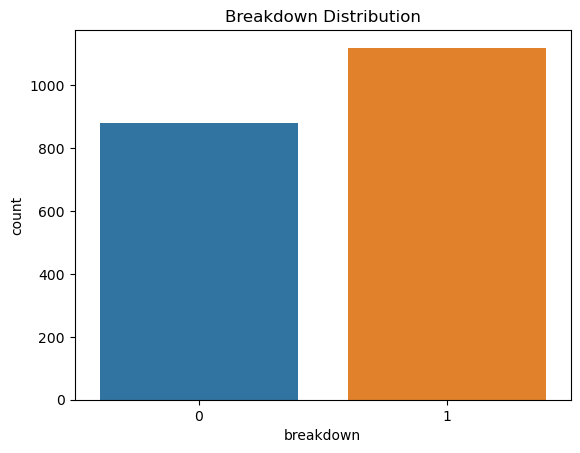

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='breakdown', data=df)
plt.title("Breakdown Distribution")
plt.show()

### Insight:
The dataset shows a relatively balanced distribution of breakdown and non-breakdown cases, making it suitable for classification modeling.

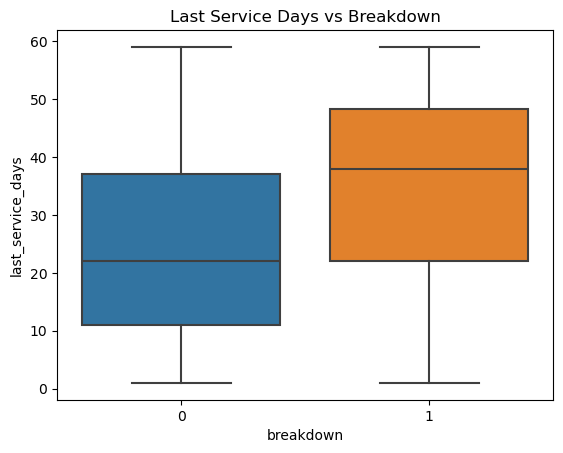

In [57]:
sns.boxplot(x='breakdown', y='last_service_days', data=df)
plt.title("Last Service Days vs Breakdown")
plt.show()

### Insight:
Vehicles with longer service intervals are significantly more likely to experience breakdowns. This highlights delayed maintenance as a key risk factor.

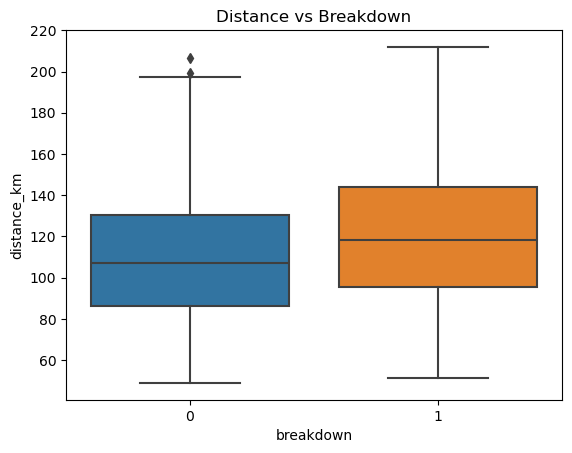

In [58]:
sns.boxplot(x='breakdown', y='distance_km', data=df)
plt.title("Distance vs Breakdown")
plt.show()

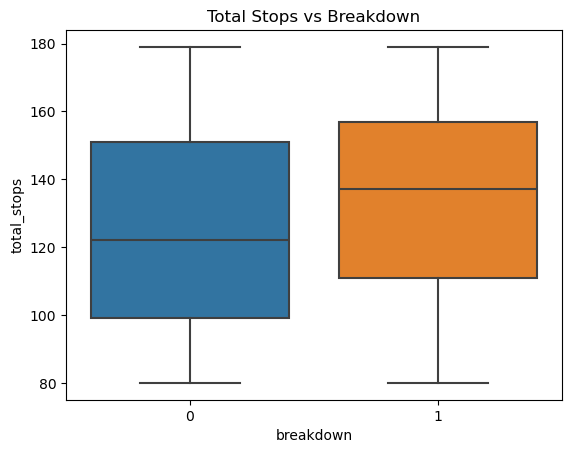

In [59]:
sns.boxplot(x='breakdown', y='total_stops', data=df)
plt.title("Total Stops vs Breakdown")
plt.show()

### Insight:
Higher travel distance and increased delivery stops are associated with higher breakdown risk, indicating operational strain on vehicles.

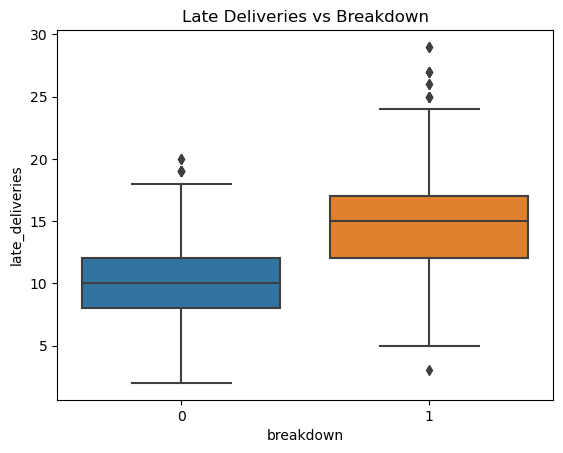

In [60]:
sns.boxplot(x='breakdown', y='late_deliveries', data=df)
plt.title("Late Deliveries vs Breakdown")
plt.show()

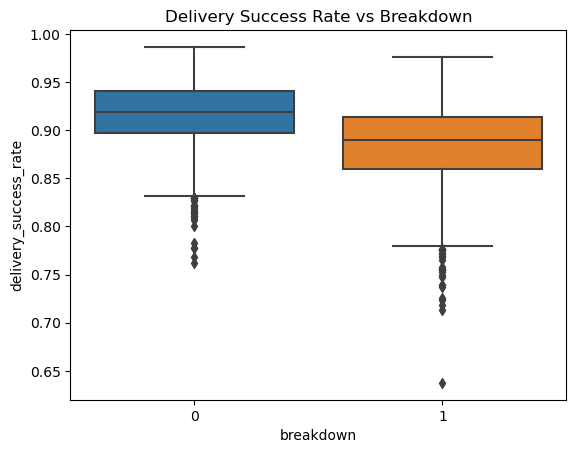

In [61]:
sns.boxplot(x='breakdown', y='delivery_success_rate', data=df)
plt.title("Delivery Success Rate vs Breakdown")
plt.show()

### Insight:
Vehicles with higher late deliveries and lower success rates tend to experience more breakdowns, linking operational inefficiency to mechanical failure.

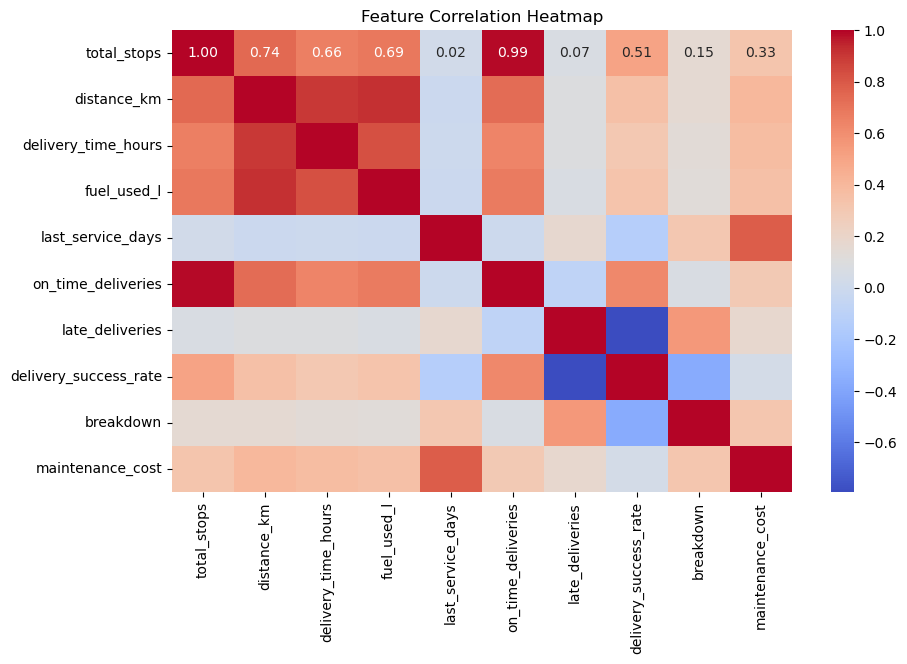

In [62]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

### Insight:
The correlation matrix shows that breakdown risk is influenced by maintenance delay, operational load, and delivery performance variables. 

The relationships appear relatively linear, which supports the effectiveness of Logistic Regression over more complex models.

## 6. Model Development

Two machine learning models were implemented to predict vehicle breakdown risk:

- Logistic Regression (baseline model)
- Random Forest (ensemble model)

These models were selected to compare linear vs non-linear approaches.

In [63]:
# Define features and target variable
X = df_cleaned.drop('breakdown', axis=1)
y = df_cleaned['breakdown']

In [64]:
X = X.drop(columns=['vehicle_id', 'driver_id'], errors='ignore')

In [65]:
# Convert categorical variables
X = pd.get_dummies(X, columns=['route_type'], drop_first=True)

# Drop date column (not needed for now)
X = X.drop('date', axis=1)

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Logistic Regression

Logistic Regression was used as a baseline model to evaluate linear relationships between operational variables and breakdown risk.

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Random Forest

Random Forest was used to capture potential non-linear relationships and compare performance against Logistic Regression.

## 7. Model Evaluation & Comparison

In [69]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, lr_pred))
print("Random Forest:\n", classification_report(y_test, rf_pred))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.71      0.74      0.72       164
           1       0.81      0.78      0.80       236

    accuracy                           0.77       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.77      0.77      0.77       400

Random Forest:
               precision    recall  f1-score   support

           0       0.71      0.76      0.73       164
           1       0.82      0.79      0.81       236

    accuracy                           0.78       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400



In [70]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print_model_results("Logistic Regression", y_test, lr_pred)
print_model_results("Random Forest", y_test, rf_pred)

# 🔥 ADD THIS HERE
print("\n=== MODEL COMPARISON ===")
print("Logistic Regression vs Random Forest")


📊 Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       164
           1       0.81      0.78      0.80       236

    accuracy                           0.77       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.77      0.77      0.77       400


📊 Random Forest Performance:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       164
           1       0.82      0.79      0.81       236

    accuracy                           0.78       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400


=== MODEL COMPARISON ===
Logistic Regression vs Random Forest


### Model Performance Insights

- Both Logistic Regression and Random Forest achieved strong and comparable performance  
- Random Forest showed slightly higher accuracy and recall  
- However, the improvement over Logistic Regression is marginal  

### Key Finding:
Although Random Forest performs slightly better, Logistic Regression remains a strong candidate due to its simplicity and interpretability.

This suggests that the dataset exhibits relatively structured relationships, where complex models provide limited additional benefit.

## 8. Business Conclusion

### Key Takeaways:

- Maintenance delays significantly increase breakdown risk  
- Operational load contributes to vehicle stress and failure  
- Delivery performance is linked to reliability issues  

### Model Insight:

Both models performed well, with Random Forest showing slightly better results.  
However, Logistic Regression provides comparable performance with greater interpretability.

### Recommendation:

For operational deployment:
- Logistic Regression is preferred for transparency and ease of use  
- Random Forest can be used for deeper analysis where marginal gains are required  

### Business Impact:

- Enables proactive maintenance scheduling  
- Reduces downtime and repair costs  
- Improves fleet reliability and service efficiency  